## 2. GPT2 from scratch
Following the textbook, here is an implementation of the GPT2 model that was created in the book. The main difference from the book is the data - the same hebrew mathematical word problems, tokens and embeddings that were produced is the previous phase. The use of hebrew needed some changes due to different tokenizer and tokenizer api.

In [80]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer

In [81]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Success: Using Apple M2 GPU Acceleration")
else:
    device = torch.device("cpu")
    print("Using CPU (Slow)")

Success: Using Apple M2 GPU Acceleration


In [82]:
text = json.load(open("output/text_stanza.json", "r", encoding="utf-8"))
vocab = sorted(set(text))
print(f"Loaded {len(text)} tokens from text.json, vocab size is {len(vocab)}")

Loaded 71815 tokens from text.json, vocab size is 4688


In [83]:
word2idx = {token: idx for idx, token in enumerate(vocab)}
idx2word = {idx: token for idx, token in enumerate(vocab)}

Loading the embeddings

In [84]:
weights_path = "output/embedding_model_stanza.pth"
state = torch.load(weights_path, map_location=device)
VOCAB_SIZE = len(vocab)
emb_tensor = None

In [85]:
if isinstance(state, dict):
    # prefer common embedding keys
    for key in (
        "in_embed.weight",
        "in_embed.weight",
        "out_embed.weight",
        "embeddings.weight",
        "embedding.weight",
        "encoder.weight",
    ):
        if (
            key in state
            and isinstance(state[key], torch.Tensor)
            and state[key].dim() == 2
        ):
            if state[key].size(0) == VOCAB_SIZE:
                emb_tensor = state[key]
                break

    # fallback: first 2D tensor whose first dim matches vocab size
    if emb_tensor is None:
        for k, v in state.items():
            if isinstance(v, torch.Tensor) and v.dim() == 2 and v.size(0) == VOCAB_SIZE:
                emb_tensor = v
                break

if emb_tensor is None:
    raise RuntimeError(
        "Couldn't find a 2D embedding tensor matching VOCAB_SIZE in the saved state_dict."
    )
emb_tensor = emb_tensor.to(device)

### 2.1 Attention

In [86]:
class SimpleAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False, hidden_dim=None):
        super(SimpleAttention, self).__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        # Compute attention scores
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        scores = queries @ keys.transpose(-2, -1)
        weights = nn.functional.softmax(scores / keys.shape[-1] ** 0.5, dim=1)

        # Compute context vector as weighted sum of values
        context_vec = weights @ values
        return context_vec

In [87]:
# simple test (ensure model and inputs are on same device)
dummy_inputs = torch.randn(10, 32, 64, device=device)  # (batch_size, seq_len, d_in)
attention = SimpleAttention(d_in=64, d_out=64).to(device)
output = attention(dummy_inputs)
print(output.shape)  # Expected: (10, 32, 64)


torch.Size([10, 32, 64])


In [88]:
sample_sentence = text[760:770]
print(f"Sample sentence: {sample_sentence}")

Sample sentence: ['מתקבל', ',', 'ה', 'תוצאה', 'תהיה', 'גדולה', 'פי', '3', 'מ', 'סכום']


In [89]:
sample_embeddings = None
emb_list = []
for t in sample_sentence:
    if t in word2idx:
        emb = emb_tensor[word2idx[t]]
        emb_list.append(emb)
sample_embeddings = torch.stack(emb_list) if emb_list else None
if sample_embeddings is None:
    raise RuntimeError("No embeddings found for sample_sentence tokens.")
sample_embeddings = sample_embeddings.to(device)
print(f"word embeddings for sample sentence: {sample_embeddings.shape}")

word embeddings for sample sentence: torch.Size([10, 200])


Dimentions fit to 200 long embeddings vector
implementing causal attention

In [90]:
class CausalAttention(nn.Module):
    def __init__(
        self, d_in, d_out, context_length, dropout, qkv_bias=False, hidden_dim=None
    ):
        super(CausalAttention, self).__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.context_length = context_length
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1).bool(),
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # Compute attention scores
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        scores = queries @ keys.transpose(1, 2)
        scores.masked_fill_(self.mask[:num_tokens, :num_tokens], float("-inf"))
        weights = nn.functional.softmax(scores / keys.shape[-1] ** 0.5, dim=-1)
        weights = self.dropout(weights)
        # Compute context vector as weighted sum of values
        context_vec = weights @ values
        return context_vec

In [91]:
attention = SimpleAttention(
    d_in=sample_embeddings.size(-1), d_out=sample_embeddings.size(-1)
).to(device)
output = attention(sample_embeddings.unsqueeze(0))  # add batch dim
print(f"Attention output shape: {output.shape}")

# instantiate causal attention
ca = CausalAttention(
    d_in=sample_embeddings.size(-1),
    d_out=sample_embeddings.size(-1),
    context_length=sample_embeddings.size(1),
    dropout=0.1,
).to(device)
causal_output = ca(sample_embeddings.unsqueeze(0))  # add batch dim
print(f"Causal attention output shape: {causal_output.shape}")

Attention output shape: torch.Size([1, 10, 200])
Causal attention output shape: torch.Size([1, 10, 200])


In [92]:
# stand alone multi-head attention, with weight split
class MultiHeadAttention(nn.Module):
    def __init__(
        self,
        d_in,
        d_out,
        context_length,
        dropout,
        num_heads,
        qkv_bias=False,
        hidden_dim=None,
    ):
        super(MultiHeadAttention, self).__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.d_head = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.context_length = context_length
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1).bool(),
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # Linear projections
        queries = (
            self.W_query(x)
            .view(b, num_tokens, self.num_heads, self.d_head)
            .transpose(1, 2)
        )
        keys = (
            self.W_key(x)
            .view(b, num_tokens, self.num_heads, self.d_head)
            .transpose(1, 2)
        )
        values = (
            self.W_value(x)
            .view(b, num_tokens, self.num_heads, self.d_head)
            .transpose(1, 2)
        )

        # Compute attention scores
        scores = queries @ keys.transpose(-2, -1)
        scores.masked_fill_(self.mask[:num_tokens, :num_tokens], float("-inf"))
        weights = nn.functional.softmax(scores / self.d_head**0.5, dim=-1)
        weights = self.dropout(weights)

        # Compute context vector as weighted sum of values
        context_vec = weights @ values
        context_vec = context_vec.transpose(1, 2).contiguous().view(b, num_tokens, -1)
        return context_vec

In [93]:
# instantiate multi-head attention
mha = MultiHeadAttention(
    d_in=sample_embeddings.size(-1),
    d_out=sample_embeddings.size(-1),
    context_length=sample_embeddings.size(1),
    dropout=0.1,
    num_heads=2,
).to(device)
mha_output = mha(sample_embeddings.unsqueeze(0))  # add batch dim
print(f"Multi-head attention output shape: {mha_output.shape}")
print(
    "Attention module tests completed successfully. As expected, all output shapes are consistent."
)

Multi-head attention output shape: torch.Size([1, 10, 200])
Attention module tests completed successfully. As expected, all output shapes are consistent.


### 2.2 GPT Model
This model is basicaly identical to the model in the book, with minor changes as explained before.

In [94]:
# config for the model
GPT_CONFIG = {
    "vocab_size": VOCAB_SIZE,  # Vocabulary size
    "context_length": 256,  # Context length
    "emb_dim": emb_tensor.shape[1],  # Embedding dimension
    "n_heads": 10,  # Number of attention heads
    "n_layers": 12,  # Number of layers
    "drop_rate": 0.1,  # Dropout rate
    "qkv_bias": False,  # Query-Key-Value bias
}

In [95]:
# GELU activation function
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return (
            0.5
            * x
            * (
                1
                + torch.tanh(
                    torch.sqrt(torch.tensor(2.0 / torch.pi))
                    * (x + 0.044715 * torch.pow(x, 3))
                )
            )
        )


In [96]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [97]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [98]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [99]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [100]:
sample_text_1 = "מחיר המכונית נמוך ממחיר"
sample_text_2 = "מחיר 3 תפוחים הוא"
tokenizer = AutoTokenizer.from_pretrained("onlplab/alephbert-base")
batch = []
batch.append(tokenizer.encode(sample_text_1))
batch.append(tokenizer.encode(sample_text_2))
batch = torch.stack([torch.tensor(b) for b in batch], dim=0).to(device)
print("Input batch shape:", batch.shape)
print("Sample batch", batch)

model = GPTModel(GPT_CONFIG).to(device)

logits = model(batch)
print("Output shape:", logits.shape)

Input batch shape: torch.Size([2, 6])
Sample batch tensor([[    2,  2041, 16078,  5249, 34003,     3],
        [    2,  2041,    23, 21549,  1884,     3]], device='mps:0')
Output shape: torch.Size([2, 6, 4688])


In [101]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [102]:
start_context = "זמן הנסיעה מתל אביב הוא"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0).to(device)  # shape (1, n_tokens)
print("encoded_tensor.shape:", encoded_tensor.shape)

model.eval()  # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG["context_length"],
)

print("Output:", out)
print("Output length:", len(out[0]))
decoded = tokenizer.decode(out[0].tolist())
print("Decoded output:", decoded)

encoded: [2, 2487, 7577, 6339, 2465, 1884, 3]
encoded_tensor.shape: torch.Size([1, 7])
Output: tensor([[   2, 2487, 7577, 6339, 2465, 1884,    3,  693,  502, 2811, 1177, 4187,
          101]], device='mps:0')
Output length: 13
Decoded output: [CLS] זמן הנסיעה מתל אביב הוא [SEP] 🌟 カמנו😪ותם ı


As expected, untrained model produces gibberish.

### 2.3 Training the model
Same as the book, except the language and start sentence

In [103]:
# token and id's functions
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [104]:
train_ratio = 0.9
split_idx = int(len(text) * train_ratio)
train_data = text[:split_idx]
val_data = text[split_idx:]

In [105]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # If txt is a list of tokens , join them into a single string
        if isinstance(txt, (list, tuple)):
            full_text = " ".join(txt)
        else:
            full_text = txt

        # Tokenize the entire text
        token_ids = tokenizer.encode(full_text)
        assert (
            len(token_ids) > max_length
        ), "Number of tokenized inputs must at least be equal to max_length+1"

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    
def create_dataloader(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0,
):

    # Initialize the tokenizer
    tokenizer = AutoTokenizer.from_pretrained("onlplab/alephbert-base")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )

    return dataloader

In [106]:
train_loader = create_dataloader(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)
# print("Train loader:")
# for x, y in train_loader:
#     print(x.shape, y.shape)

# print("\nValidation loader:")
# for x, y in val_loader:
#     print(x.shape, y.shape)

Token indices sequence length is longer than the specified maximum sequence length for this model (72544 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (8408 > 512). Running this sequence through the model will result in indexing errors


In [107]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())

    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


test loss calculations.

In [108]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    print(f"Training loss: {train_loss:.4f}")
    val_loss = calc_loss_loader(val_loader, model, device)
    print(f"Validation loss: {val_loss:.4f}")


Training loss: 6.4294
Validation loss: 6.2343


Training loop.

In [109]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [110]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

The training. 

In [111]:
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 15
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="בכיתה יש 10 תלמידים ו15 תלמידות", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 6.132, Val loss 5.735
Ep 1 (Step 000005): Train loss 5.377, Val loss 5.166
Ep 1 (Step 000010): Train loss 4.983, Val loss 4.849
Ep 1 (Step 000015): Train loss 4.626, Val loss 4.538
Ep 1 (Step 000020): Train loss 4.331, Val loss 4.287
Ep 1 (Step 000025): Train loss 4.100, Val loss 4.095
Ep 1 (Step 000030): Train loss 3.872, Val loss 3.913
Ep 1 (Step 000035): Train loss 3.856, Val loss 3.808
Ep 1 (Step 000040): Train loss 3.720, Val loss 3.740
Ep 1 (Step 000045): Train loss 3.614, Val loss 3.711
Ep 1 (Step 000050): Train loss 3.540, Val loss 3.711
Ep 1 (Step 000055): Train loss 3.453, Val loss 3.708
Ep 1 (Step 000060): Train loss 3.513, Val loss 3.693
Ep 1 (Step 000065): Train loss 3.448, Val loss 3.668
Ep 1 (Step 000070): Train loss 3.659, Val loss 3.649
Ep 1 (Step 000075): Train loss 3.530, Val loss 3.659
Ep 1 (Step 000080): Train loss 3.755, Val loss 3.695
Ep 1 (Step 000085): Train loss 3.544, Val loss 3.703
Ep 1 (Step 000090): Train loss 3.555, Val loss

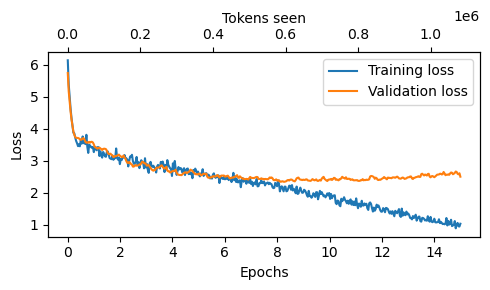

In [112]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

As expected, and similar to the results shown in the book, training on a small datset leads to overfiting.